# Pairwise pooling heatmaps (figures 5–6)

Measure how much a partner balancing authority can reduce a reference BA’s threshold-relative net-load shortfall. A small `A`/`B` example introduces the equations, then the same calculation is applied to all 110 ordered pairs of 11 regions.

**Inputs:** released historical BA scenario-metric CSVs plus the pooled `MISO_SUBREGION_SUM` CSV. The MISO label here means the sum of six subregions. Every calculation uses synchronized 2007–2023 hourly timestamps.

**Requirements:** extract the historical Zenodo collection into `data_inputs/`.

**Outputs:** `ordered_pair_metrics.csv`, four installed-portfolio heatmaps, and five synthetic-portfolio heatmaps under `data_outputs/analysis/pairwise_pooling_heatmap/`. Tables and all nine heatmaps are embedded below.

Run the code cells from top to bottom. See the [setup instructions](../../README.md#quick-start).

Rows identify the reference BA receiving a benefit; columns identify its partner. Results retain both raw and mean-load-normalized calculations. Figures 5 and 6 use the normalized branch. The CSV retains full-period totals and yearly averages; all real-data heatmaps show yearly averages over 17 years.

## Setup

In [1]:
from itertools import permutations
from pathlib import Path
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

THRESHOLD_QUANTILE = 0.95


DATA_ROOT = Path("../../data_inputs/wtk_bchrrr_nsrdb_2007_2023")

OUTPUT_DIR = Path("../../data_outputs/analysis/pairwise_pooling_heatmap")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

N_YEARS = 17

BA_CODES = [
    "BPAT",
    "CISO",
    "ERCO",
    "MISO_SUBREGION_SUM",
    "NYIS",
    "ISNE",
    "PJM",
    "SOCO",
    "SWPP",
    "TVA",
    "FPL",
]

APPENDIX_SCENARIOS = {
    "split_w100_s00": "100% Wind / 0% Solar",
    "split_w75_s25": "75% Wind / 25% Solar",
    "split_w50_s50": "50% Wind / 50% Solar",
    "split_w25_s75": "25% Wind / 75% Solar",
    "split_w00_s100": "0% Wind / 100% Solar",
}

# Shared presentation defaults; data values and plot limits are set below.
plt.rcParams.update(
    {
        "font.size": 10,
        "axes.titlesize": 12,
        "axes.titleweight": "normal",
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 9,
        "legend.frameon": False,
        "grid.color": "#d1d5db",
        "grid.linewidth": 0.7,
        "grid.alpha": 0.65,
        "figure.titlesize": 16,
        "figure.titleweight": "bold",
    }
)

## Step 1: Two-BA example and equations

Balancing authority pooling is attractive because BAs with non-coincident peaks can share resources. For example, when BA `A` is above its risk threshold and BA `B` is below its threshold, BA `B` can offset part or all of BA `A`'s shortfall (and vice versa). If both BAs are above threshold at the same time, there is no system-level surplus to reduce total shortfall; any transfer would only shift shortfall from one BA to the other. This analysis notebook uses the packaged, BA-level 2007-2023 scenario-metric dataset to calculate the benefits of interconnecting different balancing authorities with non-coincident net load peaks.

The example below shows how BA pooling benefits can be calculated from different BA net load profiles. In this example, `A` and `B` are names for two example BAs. Let the net load profile of BA `A` at time `t` be `N_A,t`, and let the net load profile of BA `B` be `N_B,t`. The threshold and threshold-relative net load are defined by the following equations:

- **Eq. 4:** $T_i = Q_{0.95}(N_i)$ is the 95th-percentile net load threshold for BA `i`, taken across all `t`. 
- **Eq. 5:** $\Delta_{i,t} = N_{i,t} - T_i$ is the amount (in MW) BA `i` is above or below its threshold at time `t`.

The code example below uses one 61-row example time series. Eq. 4 calculates `T_A = 100` and `T_B = 80` from the full 61 rows. The table below shows the first five rows as the walkthrough rows used in the prose.

| `t` | `N_A,t` | `T_A` | `Delta_A,t` | `N_B,t` | `T_B` | `Delta_B,t` |
|---|---:|---:|---:|---:|---:|---:|
| 1 | 108 | 100 | 8 | 75 | 80 | -5 |
| 2 | 102 | 100 | 2 | 70 | 80 | -10 |
| 3 | 97 | 100 | -3 | 86 | 80 | 6 |
| 4 | 96 | 100 | -4 | 78 | 80 | -2 |
| 5 | 104 | 100 | 4 | 85 | 80 | 5 |

With `Delta_A,t` and `Delta_B,t`, we can calculate how much shortfall remains after the two BAs are pooled. If one BA is above its threshold while the other is below its threshold, the below-threshold BA can offset some or all of the above-threshold BA's isolated shortfall. If both BAs are above threshold, there is no below-threshold room to reduce the pooled shortfall.

- **Eq. 6:** $d_{i,t} = \max(\Delta_{i,t}, 0)$ is the isolated shortfall for one BA `i` at time `t`.
- **Eq. 9:** $D_{S,t} = \max(\Delta_{A,t} + \Delta_{B,t}, 0)$ is the pooled shortfall after BAs `A` and `B` offset each other.
- **Eq. 10:** $\mathrm{PoolBenefit}_t = d_{A,t} + d_{B,t} - D_{S,t}$ is the shortfall avoided by pooling.
- **Eq. 11:** $\mathrm{PoolBenefitHours}_t = \mathbf{1}[(d_{A,t}>0)\lor(d_{B,t}>0)] - \mathbf{1}[D_{S,t}>0]$ counts whether pooling removes a shortfall condition in that hour.
- **Eq. 14:** $\mathrm{Alloc}_{A,t} = \min(d_{A,t}, \mathrm{PoolBenefit}_t)$ and $\mathrm{Alloc}_{B,t} = \min(d_{B,t}, \mathrm{PoolBenefit}_t)$ assign the avoided shortfall to the named BA that had isolated shortfall in that hour.

| `t` | `Delta_A` | `Delta_B` | `d_A` | `d_B` | `D_S` | `PoolBenefit` | `Alloc_A` | `Alloc_B` |
|---|---:|---:|---:|---:|---:|---:|---:|---:|
| 1 | 8 | -5 | 8 | 0 | 3 | 5 | 5 | 0 |
| 2 | 2 | -10 | 2 | 0 | 0 | 2 | 2 | 0 |
| 3 | -3 | 6 | 0 | 6 | 3 | 3 | 0 | 3 |
| 4 | -4 | -2 | 0 | 0 | 0 | 0 | 0 | 0 |
| 5 | 4 | 5 | 4 | 5 | 9 | 0 | 0 | 0 |
| **SUM** |  |  | **14** | **11** | **15** | **10** | **7** | **3** |

Avoided shortfall hours are stricter than avoided energy shortfall: they count only hours where pooling fully removes a shortfall condition. Partial reductions, such as `t = 1` and `t = 3`, reduce energy shortfall but do not count as avoided shortfall hours.

Across the five walkthrough rows, BA A's isolated shortfall is `14`, BA B's isolated shortfall is `11`, the pooled shortfall is `15`, and the total avoided shortfall is (`14` + `11` - `15`) = `10`. The allocation is not equal: BA A receives `7` units of benefit and BA B receives `3` units. BA A receives more benefit because it has shortfall in two walkthrough rows when BA B is below threshold, while BA B only has one partially offset shortfall row. The code also displays full-example totals across all 61 rows, matching the full heatmap pattern of summing over every synchronized hour.

### Shared pooling equations

These helpers are used unchanged by both the toy example and the full analysis.

In [2]:
def calculate_threshold_and_delta(net_load, threshold_quantile):
    """Calculate Eq. 4 thresholds and Eq. 5 threshold-relative net load."""

    # Eq. 4: estimate each BA's net-load threshold from the input time series.
    net_load_threshold_mw = net_load.quantile(threshold_quantile)
    # Eq. 5: subtract that BA-specific threshold from each aligned hour.
    delta_mw = net_load.subtract(net_load_threshold_mw)
    return net_load_threshold_mw, delta_mw


def calculate_reference_partner_pooling(reference_delta, partner_delta) -> pd.DataFrame:
    """Apply the two-BA pooling equations to one directional reference/partner pair."""

    table = pd.DataFrame(
        {
            "Delta_reference": pd.Series(reference_delta, dtype="float64"),
            "Delta_partner": pd.Series(partner_delta, dtype="float64"),
        }
    )

    # Eq. 6: isolated shortfall is the positive part of each BA's delta.

    table["d_reference"] = np.maximum(table["Delta_reference"], 0)
    table["d_partner"] = np.maximum(table["Delta_partner"], 0)

    # Eq. 9: pooled shortfall is symmetric for the two-BA pair.
    table["D_S"] = np.maximum(table["Delta_reference"] + table["Delta_partner"], 0)
    # Eq. 10: pooling benefit is also symmetric for the two-BA pair.
    table["PoolBenefit"] = table["d_reference"] + table["d_partner"] - table["D_S"]
    # Eq. 14: allocated benefit is directional and capped by the reference BA's isolated need.
    table["Alloc_reference"] = np.minimum(table["d_reference"], table["PoolBenefit"])

    # Eq. 11: hour-level indicator that pooling removed a shortfall condition.
    table["PoolBenefitHours"] = ((table["d_reference"] > 0) | (table["d_partner"] > 0)).astype(
        float
    ) - (table["D_S"] > 0).astype(float)
    # Eq. 11-derived: credit the avoided shortfall hour only when the reference BA had isolated
    # shortfall.
    table["Alloc_reference_Hours"] = np.minimum(
        (table["d_reference"] > 0).astype(float), table["PoolBenefitHours"]
    )

    return table

### Example inputs

`A` and `B` are example BA names; the helper uses `reference` and `partner` for the directional roles. The first five rows are the walkthrough rows shown in the prose. The full 61-row example time series is used for Eq. 4 thresholds, Eq. 5 deltas, and full-example totals.

The example uses 61 rows because `(61 - 1) * 0.95 = 57`, so pandas' default 95th-percentile calculation lands exactly on an observed row. That keeps the thresholds integer-valued while still using the same Eq. 4 calculation as the full heatmap.

In [3]:
simple_threshold_quantile = THRESHOLD_QUANTILE
walkthrough_rows = [1, 2, 3, 4, 5]

# Example input: one net-load time series used for Eq. 4 thresholds, Eq. 5 deltas, and pooling.
simple_net_load = pd.DataFrame(
    {
        "t": list(range(1, 62)),
        "A": [
            108,
            102,
            97,
            96,
            104,
            88,
            91,
            84,
            93,
            90,
            86,
            95,
            89,
            92,
            87,
            94,
            90,
            96,
            85,
            91,
            88,
            93,
            97,
            86,
            90,
            95,
            89,
            92,
            84,
            98,
            91,
            87,
            94,
            90,
            96,
            88,
            93,
            85,
            91,
            97,
            89,
            92,
            86,
            95,
            90,
            88,
            94,
            91,
            87,
            96,
            89,
            93,
            85,
            92,
            98,
            90,
            94,
            86,
            91,
            100,
            88,
        ],
        "B": [
            75,
            70,
            86,
            78,
            85,
            72,
            74,
            68,
            76,
            73,
            71,
            77,
            69,
            75,
            72,
            78,
            70,
            76,
            73,
            79,
            68,
            74,
            71,
            77,
            75,
            69,
            72,
            78,
            70,
            76,
            73,
            74,
            79,
            71,
            75,
            68,
            77,
            72,
            74,
            76,
            70,
            78,
            73,
            71,
            75,
            79,
            69,
            74,
            72,
            76,
            70,
            77,
            73,
            75,
            78,
            71,
            74,
            80,
            72,
            82,
            69,
        ],
    }
).set_index("t")

### Thresholds and walkthrough deltas

Toy net load, thresholds and deltas are in MW; each row represents one hour.

In [4]:
# Example calculation: estimate thresholds and deltas from the same input table.
simple_net_load_threshold_mw, simple_delta_mw = calculate_threshold_and_delta(
    simple_net_load, simple_threshold_quantile
)

# Display 1: confirm the 61-row example gives integer 95th-percentile thresholds.
simple_threshold_design = pd.DataFrame(
    [
        {"check": "example rows", "value": len(simple_net_load)},
        {"check": "threshold quantile", "value": simple_threshold_quantile},
        {
            "check": "quantile position",
            "value": (len(simple_net_load) - 1) * simple_threshold_quantile,
        },
        {"check": "T_A", "value": simple_net_load_threshold_mw["A"]},
        {"check": "T_B", "value": simple_net_load_threshold_mw["B"]},
        {
            "check": "A rows above threshold",
            "value": int((simple_net_load["A"] > simple_net_load_threshold_mw["A"]).sum()),
        },
        {
            "check": "B rows above threshold",
            "value": int((simple_net_load["B"] > simple_net_load_threshold_mw["B"]).sum()),
        },
    ]
)

# Display 2: net load and threshold-relative delta for the five walkthrough rows.
simple_threshold_delta_table = pd.DataFrame(
    {
        "t": walkthrough_rows,
        "net_load_A": simple_net_load.loc[walkthrough_rows, "A"].to_numpy(dtype=float),
        "T_A": simple_net_load_threshold_mw["A"],
        "Delta_A": simple_delta_mw.loc[walkthrough_rows, "A"].to_numpy(dtype=float),
        "net_load_B": simple_net_load.loc[walkthrough_rows, "B"].to_numpy(dtype=float),
        "T_B": simple_net_load_threshold_mw["B"],
        "Delta_B": simple_delta_mw.loc[walkthrough_rows, "B"].to_numpy(dtype=float),
    }
)


display(simple_threshold_design.set_index("check").style.format("{:g}"))
display(simple_threshold_delta_table.set_index("t").style.format(precision=1))

,value
check,
example rows,61
threshold quantile,0.95
quantile position,57
T_A,100
T_B,80
A rows above threshold,3
B rows above threshold,3


,net_load_A,T_A,Delta_A,net_load_B,T_B,Delta_B
t,,,,,,
1,108.0,100.0,8.0,75.0,80.0,-5.0
2,102.0,100.0,2.0,70.0,80.0,-10.0
3,97.0,100.0,-3.0,86.0,80.0,6.0
4,96.0,100.0,-4.0,78.0,80.0,-2.0
5,104.0,100.0,4.0,85.0,80.0,5.0


### Pooling and allocation for the five walkthrough rows

The same power quantities are in MW. The SUM row integrates them over the five one-hour rows (MWh); the three hour columns count fully avoided shortfall hours.

In [5]:
# Example calculation: run both directions because A and B are names, not fixed roles.
simple_a_reference_pooling = calculate_reference_partner_pooling(
    simple_delta_mw["A"], simple_delta_mw["B"]
)
simple_b_reference_pooling = calculate_reference_partner_pooling(
    simple_delta_mw["B"], simple_delta_mw["A"]
)

# Display 3: pooling outputs for the same five walkthrough rows.
# D_S and PoolBenefit are symmetric; allocation is directional, so A and B use reversed helper
# calls.

simple_pooling_display = pd.DataFrame(
    {
        "t": walkthrough_rows,
        "Delta_A": simple_delta_mw.loc[walkthrough_rows, "A"].to_numpy(dtype=float),
        "Delta_B": simple_delta_mw.loc[walkthrough_rows, "B"].to_numpy(dtype=float),
        "d_A": simple_a_reference_pooling.loc[walkthrough_rows, "d_reference"].to_numpy(
            dtype=float
        ),
        "d_B": simple_b_reference_pooling.loc[walkthrough_rows, "d_reference"].to_numpy(
            dtype=float
        ),
        "D_S": simple_a_reference_pooling.loc[walkthrough_rows, "D_S"].to_numpy(dtype=float),
        "PoolBenefit": simple_a_reference_pooling.loc[walkthrough_rows, "PoolBenefit"].to_numpy(
            dtype=float
        ),
        "PoolBenefitHours": simple_a_reference_pooling.loc[
            walkthrough_rows, "PoolBenefitHours"
        ].to_numpy(dtype=float),
        "Alloc_A": simple_a_reference_pooling.loc[walkthrough_rows, "Alloc_reference"].to_numpy(
            dtype=float
        ),
        "Alloc_B": simple_b_reference_pooling.loc[walkthrough_rows, "Alloc_reference"].to_numpy(
            dtype=float
        ),
        # Eq. 11 counts only hours where pooling fully removes the shortfall condition. Partial
        # reductions appear in Alloc_A or Alloc_B, but their hour allocation remains 0.
        "Alloc_A_Hours": simple_a_reference_pooling.loc[
            walkthrough_rows, "Alloc_reference_Hours"
        ].to_numpy(dtype=float),
        "Alloc_B_Hours": simple_b_reference_pooling.loc[
            walkthrough_rows, "Alloc_reference_Hours"
        ].to_numpy(dtype=float),
    }
)

sum_columns = [
    "d_A",
    "d_B",
    "D_S",
    "PoolBenefit",
    "PoolBenefitHours",
    "Alloc_A",
    "Alloc_B",
    "Alloc_A_Hours",
    "Alloc_B_Hours",
]

simple_pooling_sum_row = {
    "t": "SUM",
    "Delta_A": "",
    "Delta_B": "",
}
for column in sum_columns:
    simple_pooling_sum_row[column] = simple_pooling_display[column].sum()

simple_pooling_display = pd.concat(
    [simple_pooling_display, pd.DataFrame([simple_pooling_sum_row])], ignore_index=True
)


display(
    simple_pooling_display.set_index("t")
    .style.format(precision=1)
    .format(
        "{:.0f}",
        subset=["PoolBenefitHours", "Alloc_A_Hours", "Alloc_B_Hours"],
    )
)

,Delta_A,Delta_B,d_A,d_B,D_S,PoolBenefit,PoolBenefitHours,Alloc_A,Alloc_B,Alloc_A_Hours,Alloc_B_Hours
t,,,,,,,,,,,
1,8.0,-5.0,8.0,0.0,3.0,5.0,0,5.0,0.0,0,0
2,2.0,-10.0,2.0,0.0,0.0,2.0,1,2.0,0.0,1,0
3,-3.0,6.0,0.0,6.0,3.0,3.0,0,0.0,3.0,0,0
4,-4.0,-2.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0,0
5,4.0,5.0,4.0,5.0,9.0,0.0,0,0.0,0.0,0,0
SUM,,,14.0,11.0,15.0,10.0,1,7.0,3.0,1,0


### Full-example totals and arithmetic checks

Energy totals are in MWh; `PoolBenefitHours`, `Alloc_A_Hours` and `Alloc_B_Hours` are in hours.

In [6]:
# Display 4: sums across all 61 rows, matching the full heatmap sum-over-hours pattern.
simple_pooling_totals = pd.Series(
    {
        "d_A": simple_a_reference_pooling["d_reference"].sum(),
        "d_B": simple_b_reference_pooling["d_reference"].sum(),
        "D_S": simple_a_reference_pooling["D_S"].sum(),
        "PoolBenefit": simple_a_reference_pooling["PoolBenefit"].sum(),
        "PoolBenefitHours": simple_a_reference_pooling["PoolBenefitHours"].sum(),
        "Alloc_A": simple_a_reference_pooling["Alloc_reference"].sum(),
        "Alloc_B": simple_b_reference_pooling["Alloc_reference"].sum(),
        "Alloc_A_Hours": simple_a_reference_pooling["Alloc_reference_Hours"].sum(),
        "Alloc_B_Hours": simple_b_reference_pooling["Alloc_reference_Hours"].sum(),
    },
    name="All 61 rows",
).to_frame()

display(
    simple_pooling_totals.style.format(precision=1).format(
        "{:.0f}",
        subset=pd.IndexSlice[["PoolBenefitHours", "Alloc_A_Hours", "Alloc_B_Hours"], :],
    )
)

# Check the arithmetic stated in the five-row walkthrough.
assert len(simple_net_load) == 61
assert simple_net_load_threshold_mw.to_dict() == {"A": 100.0, "B": 80.0}
assert simple_a_reference_pooling.loc[walkthrough_rows, "Alloc_reference"].sum() == 7
assert simple_b_reference_pooling.loc[walkthrough_rows, "Alloc_reference"].sum() == 3
assert simple_a_reference_pooling.loc[walkthrough_rows, "Alloc_reference_Hours"].sum() == 1
assert simple_b_reference_pooling.loc[walkthrough_rows, "Alloc_reference_Hours"].sum() == 0

,All 61 rows
d_A,14.0
d_B,13.0
D_S,17.0
PoolBenefit,10.0
PoolBenefitHours,1
Alloc_A,7.0
Alloc_B,3.0
Alloc_A_Hours,1
Alloc_B_Hours,0


## Step 2: Read and synchronize hourly BA data

The heatmap metrics sum hourly pooling results, so every BA must be aligned to the same UTC timestamps before any pairwise calculation. This step reads one packaged scenario-metric CSV for each BA in `BA_CODES`, retains the installed-case load and the net load for all six requested portfolios, and aligns each portfolio independently. Each source CSV is read once; the synthetic-portfolio appendix reuses these same tables.

`load` provides the average-load denominator used for mean-load normalization. `net_load` provides the net-load values used to calculate thresholds and threshold-relative shortfall.

The MISO heatmap entry uses `MISO_SUBREGION_SUM`, the aggregate of the six MISO subregions. It is distinct from the direct `MISO` BA series used in the monthly event-count notebook.

In [7]:
# Read each BA file once, retaining all requested portfolios and only installed-case load.
net_load_by_scenario = {}
for scenario in ["installed_2024", *APPENDIX_SCENARIOS]:
    net_load_by_scenario[scenario] = {}
installed_load_by_ba = {}
for ba_code in BA_CODES:
    folder = "pooled_scenario_metrics" if ba_code == "MISO_SUBREGION_SUM" else "ba_scenario_metrics"
    path = DATA_ROOT / folder / f"{ba_code}_wtk_bchrrr_nsrdb_2007_2023_scenario_metrics.csv"
    frame = pd.read_csv(path, usecols=["time_utc", "scenario", "load_mw", "net_load_mw"])
    frame = frame.loc[frame["scenario"].isin(net_load_by_scenario)].copy()
    frame["time_utc"] = pd.to_datetime(frame["time_utc"], utc=True)

    installed_rows = frame.loc[frame["scenario"].eq("installed_2024")]
    if installed_rows.empty:
        raise AssertionError(f"Missing installed_2024 rows for {ba_code}.")
    installed_load_by_ba[ba_code] = installed_rows.set_index("time_utc")["load_mw"]

    for scenario, scenario_rows in frame.groupby("scenario", sort=False):
        # Pivot rejects duplicate timestamps within a BA/portfolio; absent portfolios stay absent.
        net_load_by_scenario[scenario][ba_code] = scenario_rows.pivot(
            index="time_utc", columns="scenario", values="net_load_mw"
        )[scenario]

# Align each portfolio independently and preserve the configured BA order.
aligned_net_load = {}
for scenario, by_ba in net_load_by_scenario.items():
    scenario_table = pd.DataFrame(by_ba).sort_index()
    aligned_net_load[scenario] = scenario_table.rename_axis(columns="ba_code")
net_load_by_scenario = aligned_net_load

load = pd.DataFrame(installed_load_by_ba).sort_index()
load = load.rename_axis(columns="ba_code")
net_load = net_load_by_scenario["installed_2024"]
del frame, installed_rows, scenario_rows, installed_load_by_ba

assert load.columns.tolist() == BA_CODES, "Every selected BA needs installed_2024 rows."
assert load.index.equals(net_load.index)
assert len(load) == N_YEARS * 8760
assert load.notna().all().all() and net_load.notna().all().all()
print(
    f"Synchronized {len(load):,} hourly rows for {len(BA_CODES)} regions ({load.index.min()} to {load.index.max()})."
)

Synchronized 148,920 hourly rows for 11 regions (2007-01-01 00:00:00+00:00 to 2023-12-31 23:00:00+00:00).


## Step 3: Build pairwise equation inputs

The real-data `net_load` table plays the same role as `simple_net_load` in the toy example. The same equations calculate each BA's threshold, `threshold_mw`, and raw threshold-relative net load, `delta_mw`.

For the mean-load-normalized heatmaps, the notebook first converts `Delta_i,t` to a load-relative value:

- **Eq. 7:** $L_i = \operatorname{mean}_t(\mathrm{load}_{i,t})$ is BA `i`'s average load over the synchronized 2007-2023 analysis period. The packaged time series use 8760 hourly timestamps per year, so leap-day hours are not included.
- **Eq. 8:** $\Delta^{\mathrm{norm}}_{i,t} = \Delta_{i,t}/L_i = (N_{i,t}-T_i)/L_i$ is the threshold-relative net load divided by average load. This value is no longer in MW; it is a load-relative measure of how far above or below threshold the BA is.

The denominator is average load, not average net load. The numerator already measures net-load stress, so the denominator is only meant to scale that stress by BA size. Using average net load would make the scale depend on the renewable generation in the selected scenario, which would mix the size adjustment with renewable-penetration effects.

`mean_load_mw` holds each BA's average load (`L_i`), and `normalized_delta` is `delta_mw` divided by `mean_load_mw`. The pooling helper is the same for the raw and mean-load-normalized branches; only the input series changes.

In [8]:
# Eq. 4 and Eq. 5: same helper used in the simple two-BA example.
threshold_mw, delta_mw = calculate_threshold_and_delta(net_load, THRESHOLD_QUANTILE)

# Eq. 7: average load, not average net load, is the BA-size denominator.
mean_load_mw = load.mean()

# Eq. 8: divide each BA's delta by that BA's average load.
normalized_delta = delta_mw / mean_load_mw

assert threshold_mw.notna().all()
assert mean_load_mw.gt(0).all()
assert np.isfinite(delta_mw.to_numpy(dtype=float)).all()
assert np.isfinite(normalized_delta.to_numpy(dtype=float)).all()

## Step 4: Calculate every ordered pair

This step applies the two-BA pooling helper to every ordered reference BA / partner BA pair and stores the summed results in `ordered_pairs`.

Each row in `ordered_pairs` is one directional pair. The loop calculates raw avoided energy shortfall, mean-load-normalized avoided energy shortfall, raw avoided shortfall hours, and mean-load-normalized avoided shortfall hours. The calculation then pivots those rows into the four heatmap matrices.

Full-period totals are retained in the CSV. Each plotted matrix uses the corresponding total divided by `N_YEARS = 17`.

In [9]:
def summarize_ordered_pairs(delta, prefix=""):
    """Sum the same hourly allocations used in the toy example for every pair."""
    rows = []
    for reference_ba, partner_ba in permutations(delta.columns, 2):
        pooling = calculate_reference_partner_pooling(delta[reference_ba], delta[partner_ba])
        rows.append(
            {
                "reference_ba": reference_ba,
                "partner_ba": partner_ba,
                f"{prefix}avoided_energy_shortfall_total": pooling["Alloc_reference"].sum(),
                f"{prefix}avoided_shortfall_hours_total": pooling["Alloc_reference_Hours"].sum(),
            }
        )
    return pd.DataFrame(rows)


normalized_pairs = summarize_ordered_pairs(normalized_delta)
raw_pairs = summarize_ordered_pairs(delta_mw, prefix="raw_")
ordered_pairs = normalized_pairs.merge(
    raw_pairs,
    on=["reference_ba", "partner_ba"],
    validate="one_to_one",
)
# Annualize the data itself so colors, annotations, and colorbars agree.
for metric in (
    "avoided_energy_shortfall",
    "avoided_shortfall_hours",
    "raw_avoided_energy_shortfall",
    "raw_avoided_shortfall_hours",
):
    ordered_pairs[f"{metric}_per_year"] = ordered_pairs[f"{metric}_total"] / N_YEARS

assert len(ordered_pairs) == len(BA_CODES) * (len(BA_CODES) - 1)
assert ordered_pairs.filter(like="avoided").ge(-1e-9).all().all()
ordered_pairs.to_csv(OUTPUT_DIR / "ordered_pair_metrics.csv", index=False)

energy_per_year = ordered_pairs.pivot(
    index="reference_ba", columns="partner_ba", values="avoided_energy_shortfall_per_year"
).reindex(index=BA_CODES, columns=BA_CODES)
hours_per_year = ordered_pairs.pivot(
    index="reference_ba", columns="partner_ba", values="avoided_shortfall_hours_per_year"
).reindex(index=BA_CODES, columns=BA_CODES)
raw_energy_per_year = ordered_pairs.pivot(
    index="reference_ba", columns="partner_ba", values="raw_avoided_energy_shortfall_per_year"
).reindex(index=BA_CODES, columns=BA_CODES)
raw_hours_per_year = ordered_pairs.pivot(
    index="reference_ba", columns="partner_ba", values="raw_avoided_shortfall_hours_per_year"
).reindex(index=BA_CODES, columns=BA_CODES)

# A BA is not paired with itself, so every matrix has a blank diagonal.
for matrix in (energy_per_year, hours_per_year, raw_energy_per_year, raw_hours_per_year):
    assert np.isnan(np.diag(matrix.to_numpy(dtype=float))).all()
print("Two directions for BPA and CAISO · Mean-load normalized · Annual averages, 2007–2023.")
pair_preview = ordered_pairs.set_index(["reference_ba", "partner_ba"])
pair_preview = pair_preview.loc[
    [("BPAT", "CISO"), ("CISO", "BPAT")],
    ["avoided_energy_shortfall_per_year", "avoided_shortfall_hours_per_year"],
]
pair_preview = pair_preview.rename(
    index={"BPAT": "BPA", "CISO": "CAISO"},
    columns={
        "avoided_energy_shortfall_per_year": "Avoided energy shortfall (mean-load hours/year)",
        "avoided_shortfall_hours_per_year": "Avoided shortfall hours (hours/year)",
    },
)
pair_preview = pair_preview.rename_axis(index=["Reference BA", "Partner BA"])
display(pair_preview.style.format("{:,.3f}"))

Two directions for BPA and CAISO · Mean-load normalized · Annual averages, 2007–2023.


,,Avoided energy shortfall (mean-load hours/year),Avoided shortfall hours (hours/year)
Reference BA,Partner BA,,
BPA,CAISO,35.686,369.471
CAISO,BPA,52.918,359.059


## Step 5: Plot pairwise heatmaps

This step plots the four heatmap matrices from the previous step. The two normalized plots are Figures 5 and 6. Two additional plots show raw energy and hours for comparison.

The same yearly-average matrices supply the colors, annotations, and colorbars; no display-only scaling is applied.

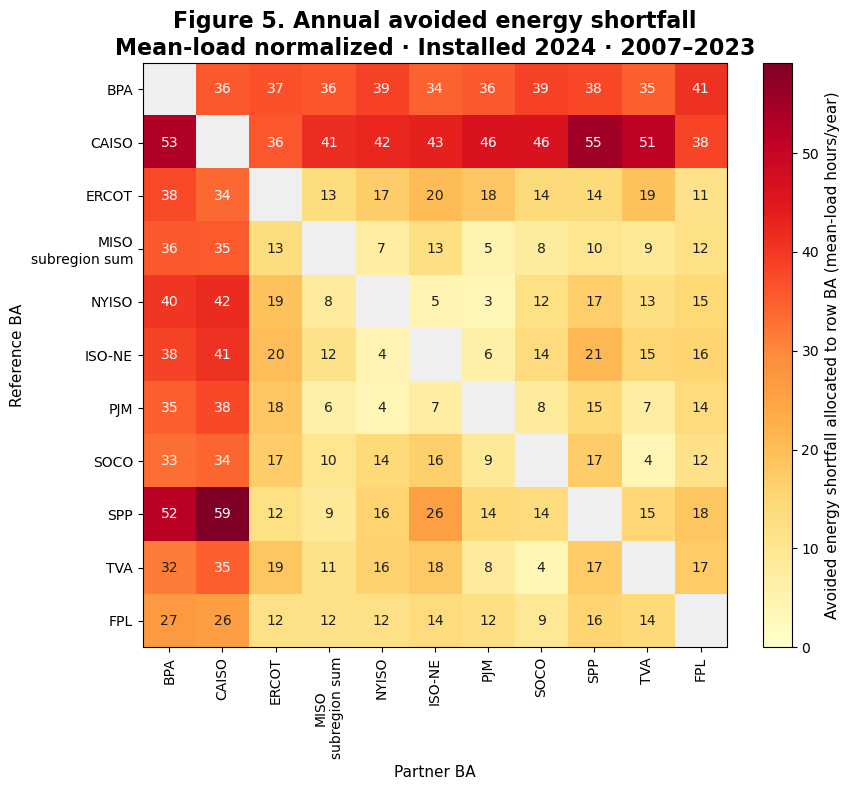

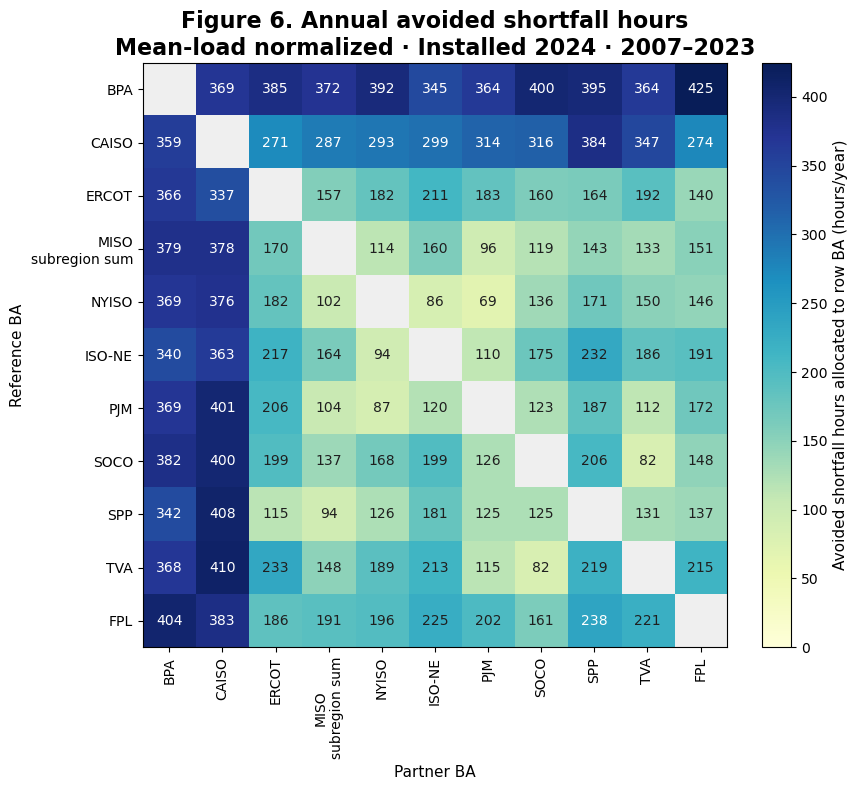

Wrote normalized heatmaps: ../../data_outputs/analysis/pairwise_pooling_heatmap/figure_5_mean_load_normalized_avoided_energy_shortfall.png and ../../data_outputs/analysis/pairwise_pooling_heatmap/figure_6_mean_load_normalized_avoided_shortfall_hours.png


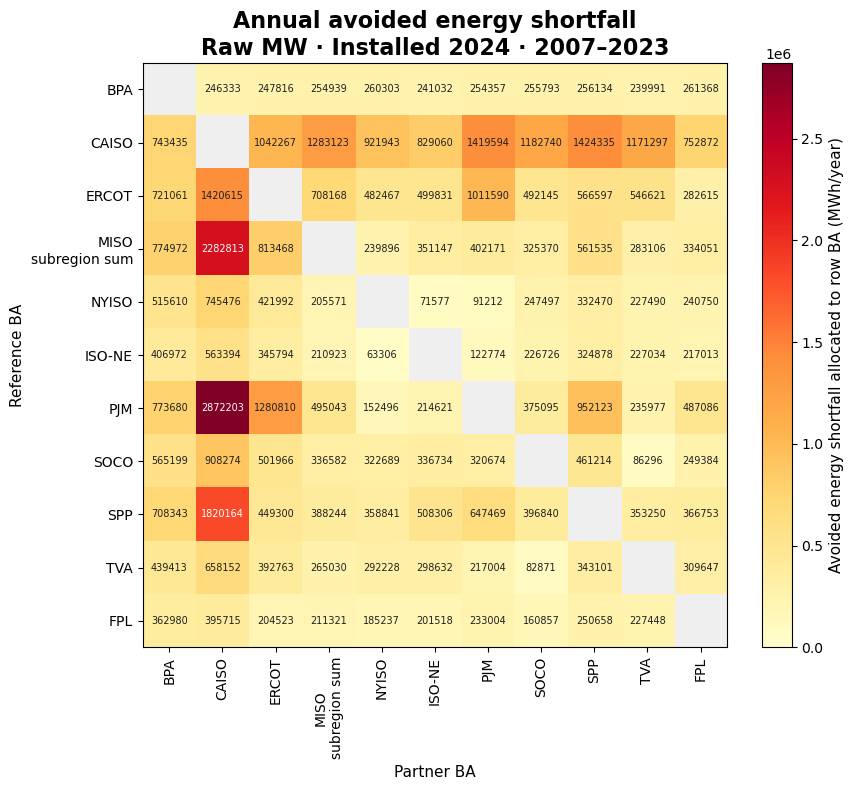

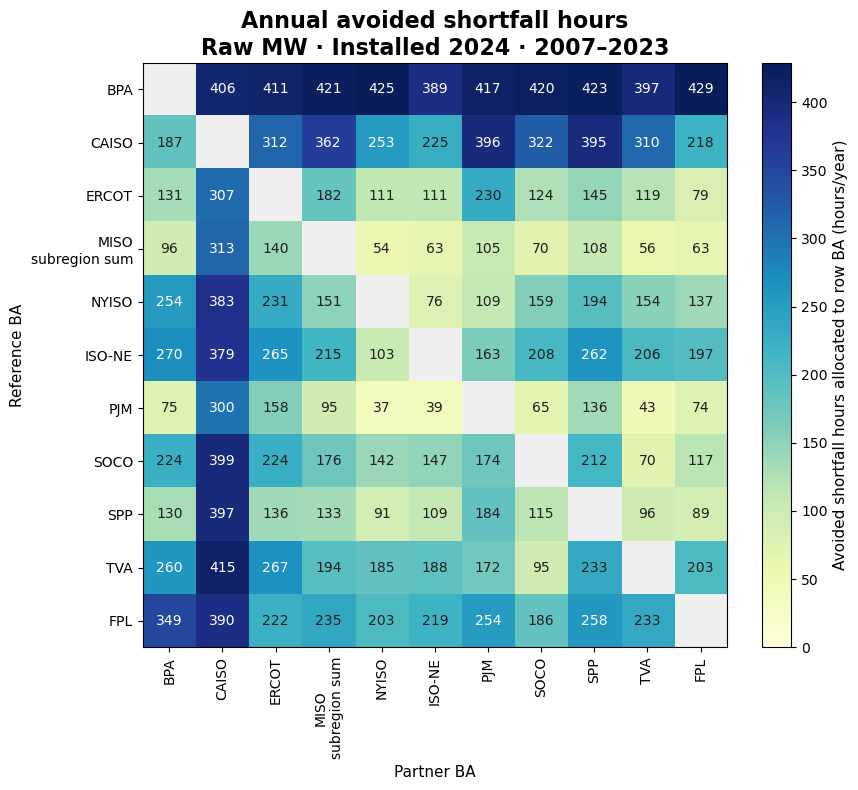

In [10]:
LABELS = {
    "BPAT": "BPA",
    "CISO": "CAISO",
    "ERCO": "ERCOT",
    "MISO_SUBREGION_SUM": "MISO\nsubregion sum",
    "NYIS": "NYISO",
    "ISNE": "ISO-NE",
    "PJM": "PJM",
    "SOCO": "SOCO",
    "SWPP": "SPP",
    "TVA": "TVA",
    "FPL": "FPL",
}


def plot_pairwise_heatmap(
    matrix, title, output_path, cmap_name, colorbar_label, vmax=None, annotation_fontsize=10
):
    values = matrix.to_numpy(dtype=float)
    finite = values[np.isfinite(values)]
    if vmax is None:
        vmax = max(float(finite.max()), 1.0)
    labels = [LABELS.get(code, code) for code in BA_CODES]

    fig, ax = plt.subplots(figsize=(10, 8))
    cmap = plt.get_cmap(cmap_name).copy()
    cmap.set_bad("#efefef")
    image = ax.imshow(np.ma.masked_invalid(values), cmap=cmap, vmin=0, vmax=vmax)
    ax.set_xticks(range(len(labels)), labels, rotation=90)
    ax.set_yticks(range(len(labels)), labels)
    ax.set_title(title, fontsize=16, fontweight="bold")
    ax.set_xlabel("Partner BA")
    ax.set_ylabel("Reference BA")
    for row in range(len(labels)):
        for column in range(len(labels)):
            value = values[row, column]
            if np.isfinite(value):
                color = "white" if value >= 0.55 * vmax else "#1f1f1f"
                ax.text(
                    column,
                    row,
                    f"{value:.0f}",
                    ha="center",
                    va="center",
                    fontsize=annotation_fontsize,
                    color=color,
                )
    colorbar = fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    colorbar.set_label(colorbar_label)
    fig.tight_layout()
    fig.savefig(output_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close(fig)


figure_5_path = OUTPUT_DIR / "figure_5_mean_load_normalized_avoided_energy_shortfall.png"
figure_6_path = OUTPUT_DIR / "figure_6_mean_load_normalized_avoided_shortfall_hours.png"
plot_pairwise_heatmap(
    energy_per_year,
    "Figure 5. Annual avoided energy shortfall\nMean-load normalized · Installed 2024 · 2007–2023",
    figure_5_path,
    "YlOrRd",
    "Avoided energy shortfall allocated to row BA (mean-load hours/year)",
)
plot_pairwise_heatmap(
    hours_per_year,
    "Figure 6. Annual avoided shortfall hours\nMean-load normalized · Installed 2024 · 2007–2023",
    figure_6_path,
    "YlGnBu",
    "Avoided shortfall hours allocated to row BA (hours/year)",
)
print(f"Wrote normalized heatmaps: {figure_5_path.as_posix()} and {figure_6_path.as_posix()}")
# Raw-MW comparisons use the same plotting function and yearly aggregation.
plot_pairwise_heatmap(
    raw_energy_per_year,
    "Annual avoided energy shortfall\nRaw MW · Installed 2024 · 2007–2023",
    OUTPUT_DIR / "figure_5_raw_avoided_energy_shortfall.png",
    "YlOrRd",
    "Avoided energy shortfall allocated to row BA (MWh/year)",
    annotation_fontsize=7,
)
plot_pairwise_heatmap(
    raw_hours_per_year,
    "Annual avoided shortfall hours\nRaw MW · Installed 2024 · 2007–2023",
    OUTPUT_DIR / "figure_6_raw_avoided_shortfall_hours.png",
    "YlGnBu",
    "Avoided shortfall hours allocated to row BA (hours/year)",
)

## Interpretation

Higher cells indicate more benefit allocated to the row BA from that partner. Energy can improve without fully removing shortfall hours. Normalization divides each BA’s delta by its own **mean load before pooling**, so it can also change which hours receive full relief. Scenario-specific thresholds measure complementarity within each portfolio’s own high-risk tail; the stress-event catalog uses shared thresholds to compare how portfolios change stress.

## Appendix A: Synthetic portfolio scenarios

Figure 5 uses the installed 2024 wind/solar portfolio for each BA. This appendix repeats the mean-load-normalized avoided-energy-shortfall heatmap for five synthetic portfolio scenarios: 100% wind, 75% wind / 25% solar, 50% wind / 50% solar, 25% wind / 75% solar, and 100% solar.

The synthetic portfolio scenarios ensure that each BA has the same wind/solar share in a given panel. This allows an equal comparison of hypothetical scenarios, and it can remove the impact of BA-specific wind/solar ratios and therefore better isolate the benefits due to load and meteorological patterns across BAs. It also shows how the relative pooling benefits between BAs vary as a function of resource mix; for example, BAs that have complementary wind CF profiles but a similar solar CF profile could see more relative benefits in a 100% wind scenario than a 100% solar scenario.

### Scenario-specific vs grouped thresholds

[BA scenario metrics generation](../data_flow/ba_scenario_metrics_generation.ipynb) shows how installed and synthetic wind/solar portfolio scenarios are created from load, renewable CF, and scenario capacity assumptions. Once those scenarios exist, there are two useful ways to calculate thresholds. Scenario-specific thresholds calculate one threshold per BA within each scenario. Grouped thresholds calculate one threshold per BA across all scenarios in a metric family.

This appendix uses scenario-specific thresholds because the pooling question is: within this portfolio scenario's own high-risk tail, which partner BA is complementary? The [stress-event method](../data_flow/ba_stress_event_catalog.ipynb) notebook uses grouped thresholds instead because its question is: against the same BA-specific risk yardstick, how do event frequency, duration, and timing shift across scenarios? Both views are useful for planning: pooling shows complementarity conditional on stress, while the stress event catalog shows how portfolio choices shift the stress events themselves.

`SOCO` and `FPL` are solar-only in the packaged EIA-860 2024 filtered inputs. As such, they appear in the 100% solar panel only and are grayed-out in the other scenarios. The appendix reads their available `split_w00_s100` rows, which match their installed solar-only series. Their rows and columns remain grey in the other four split panels.

Each synthetic scenario uses its own P95 threshold and the same mean-load denominator as the installed case. All five matrices are divided by 17 before plotting, and share one color scale in mean-load hours/year.

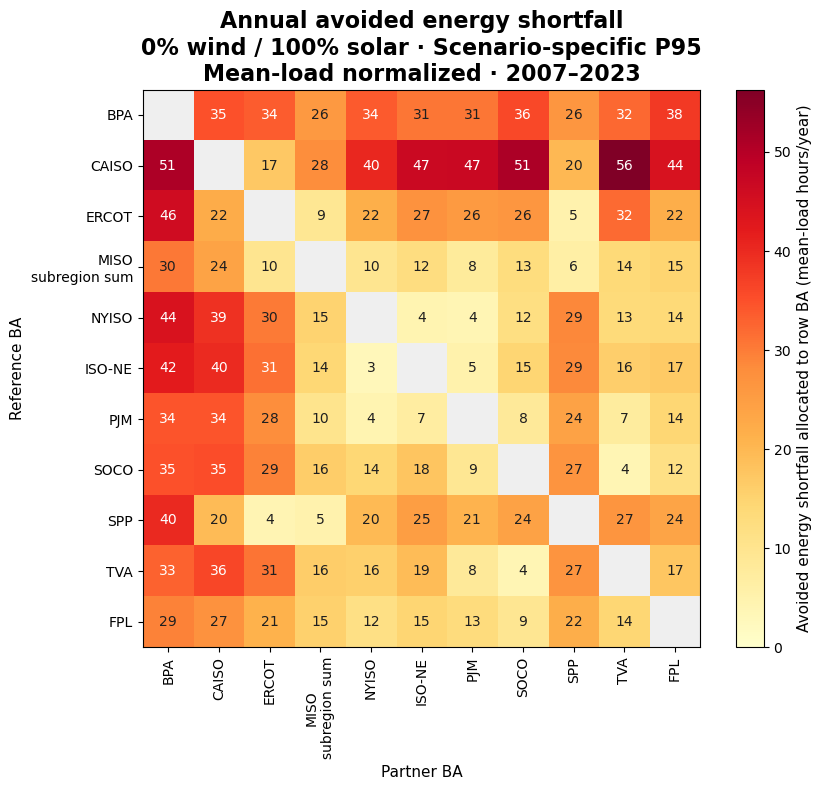

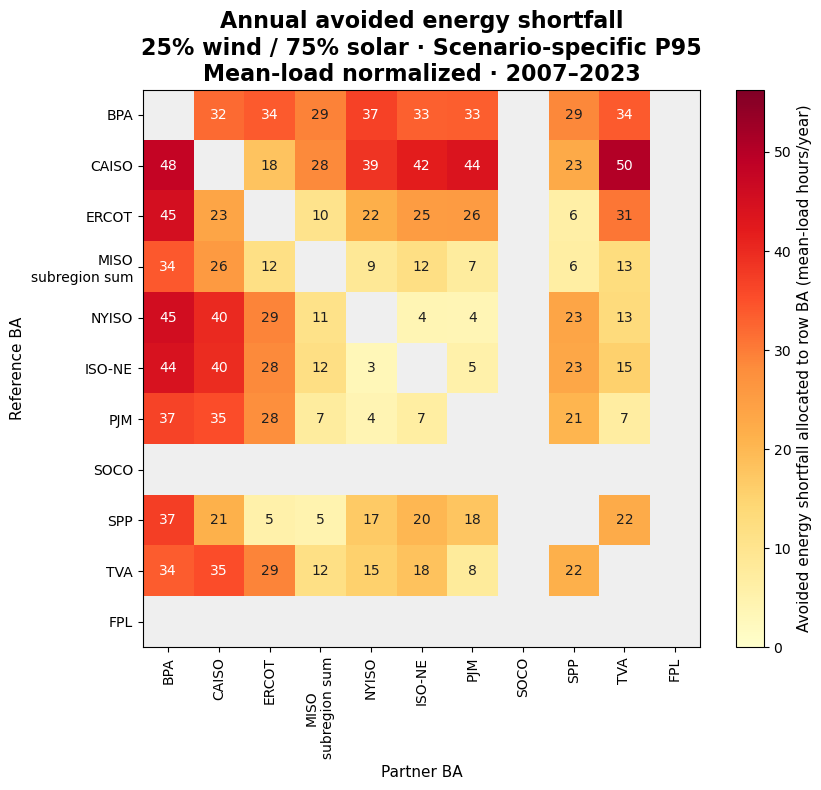

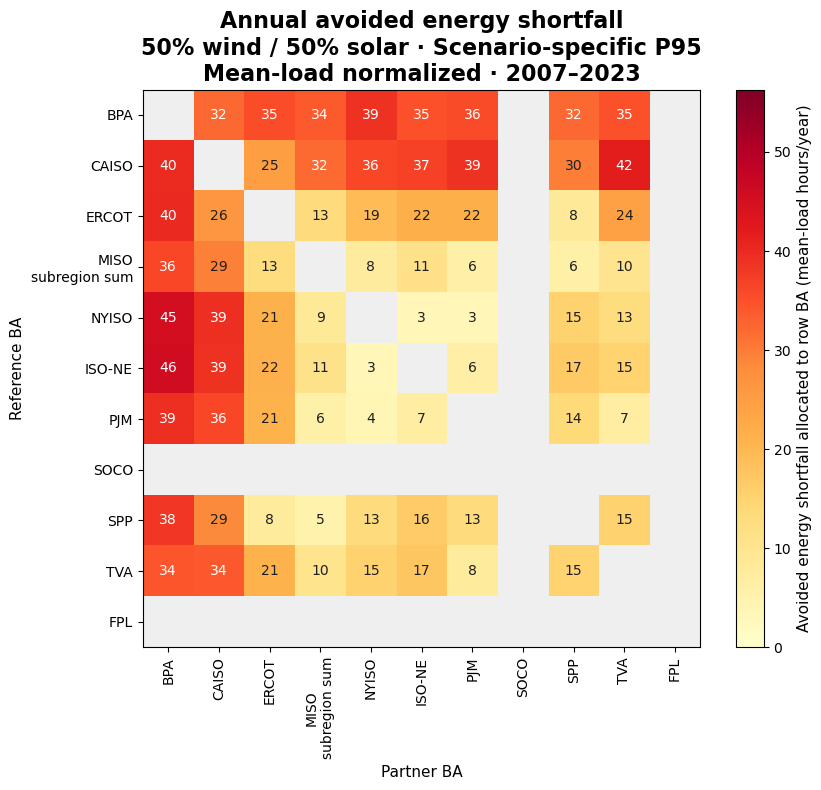

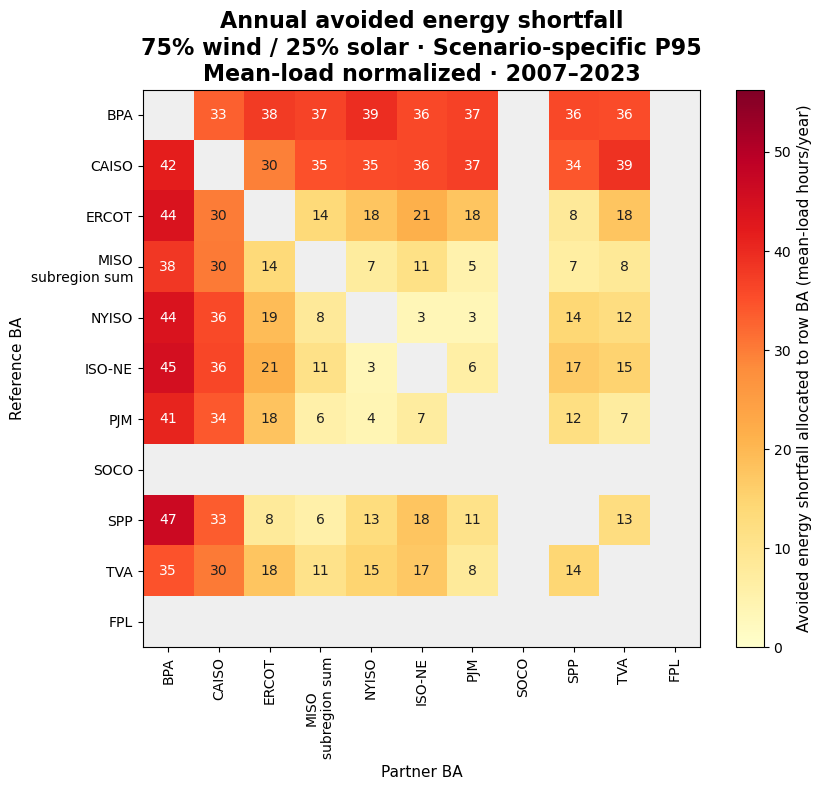

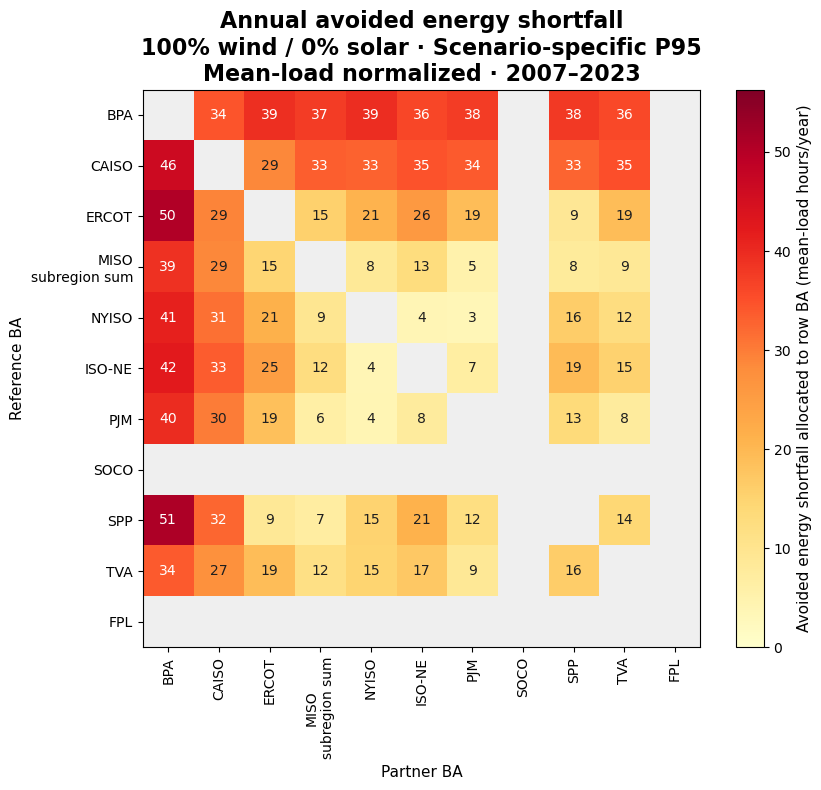

In [11]:
appendix_heatmap_matrices = {}
for scenario in APPENDIX_SCENARIOS:
    scenario_net_load = net_load_by_scenario[scenario]
    assert scenario_net_load.index.equals(load.index)
    assert scenario_net_load.notna().all().all()

    # Each portfolio gets its own P95; BA-size normalization uses installed-case mean load.
    _, scenario_delta = calculate_threshold_and_delta(scenario_net_load, THRESHOLD_QUANTILE)
    normalized_scenario_delta = scenario_delta / mean_load_mw[scenario_net_load.columns]
    pairs = summarize_ordered_pairs(normalized_scenario_delta)
    pairs["avoided_energy_shortfall_per_year"] = pairs["avoided_energy_shortfall_total"] / N_YEARS
    appendix_heatmap_matrices[scenario] = pairs.pivot(
        index="reference_ba", columns="partner_ba", values="avoided_energy_shortfall_per_year"
    ).reindex(index=BA_CODES, columns=BA_CODES)

# Unavailable portfolios and self-pairs stay blank; all five panels use one color scale.
finite_values_by_scenario = []
for matrix in appendix_heatmap_matrices.values():
    values = matrix.to_numpy()
    finite_values_by_scenario.append(values[np.isfinite(values)])
appendix_finite_values = np.concatenate(finite_values_by_scenario)
appendix_vmax = float(appendix_finite_values.max()) if appendix_finite_values.size else 1.0
if appendix_vmax <= 0.0:
    appendix_vmax = 1.0

# Presentation order follows the same ascending wind shares as the scenario comparisons.
for scenario in (
    "split_w00_s100",
    "split_w25_s75",
    "split_w50_s50",
    "split_w75_s25",
    "split_w100_s00",
):
    label = APPENDIX_SCENARIOS[scenario].lower()
    plot_pairwise_heatmap(
        appendix_heatmap_matrices[scenario],
        f"Annual avoided energy shortfall\n"
        f"{label} · Scenario-specific P95\n"
        f"Mean-load normalized · 2007–2023",
        OUTPUT_DIR / f"appendix_{scenario}_avoided_energy_shortfall.png",
        "YlOrRd",
        "Avoided energy shortfall allocated to row BA (mean-load hours/year)",
        vmax=appendix_vmax,
    )